# v3 — Maynard treatment trajectory: persister-state reprogramming in EGFR-mutant lung cancer, and why it is not a stiffness test

**Dataset.** Maynard et al. 2020 (PRJNA591860), Smart-seq2, 49 biopsies / 30 patients, EGFR/ALK/etc. lung adenocarcinoma sampled across the treatment axis: treatment-naive (**TN**), residual disease (**RD**, the drug-tolerant persister state), and progressive disease (**PD**).

**What this notebook shows, in order.** (1) The malignant compartment is cleanly resolved — the cleanest inferCNV diagnostics in the project, thanks to uniform Smart-seq2 depth (no depth confound). (2) On EGFR malignant cells across TN→RD→PD, the model-node signatures show large, monotone **cell-level** effects, and the authors' alveolar-regenerative (AT2) persister signature fires as a positive control. (3) **The honest turn:** those cell-level p-values are pseudoreplication — aggregated to the patient level (N=5/5/3), almost nothing survives. (4) **The interpretive turn:** the one effect that holds directionally per-donor — a collapse of cyclin D–CDK4/6 — is the *opposite* of the stiffness prediction and reflects persister quiescence (TKI → cell-cycle exit), not a soft→stiff transition. The treatment axis confounds drug exposure, selection, and time; it is not a stiffness contrast and cannot test whether cancer cells raise mechanotransduction *in response to stiffness*.

> **Bottom line.** Maynard is excellent *persister biology* and a clean malignant-calling exercise, but it answers a different question than the stiffness model's cancer-cell-response prediction. That prediction needs a soft-vs-stiff contrast, which dissociated patient biopsies on a treatment axis do not provide.

## 1 · Setup — load the CNV result, attach treatment stage and sequencing depth

We read `results_maynard/cnv/cnv.h5ad` (malignant calls already made), and re-attach `total_counts` from the per-sample resources files (depth is dropped during the CNV concat, and we want it to *prove the absence* of the depth confound that limited Kim). The `score_sig` helper scores only genes present in `var_names`, robust to symbol drift.

In [1]:
import re, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.stats import mannwhitneyu, kruskal
from pathlib import Path
import os

In [2]:
d = Path.cwd()
while not (d / 'workflow').is_dir() and d != d.parent:
    d = d.parent
os.chdir(d)
print('repo root:', d)

repo root: C:\Users\olesk\repos\lung_stiffness_RNAseq


In [3]:
sc.settings.verbosity = 0
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

A = sc.read_h5ad('results_maynard/cnv/cnv.h5ad')

# re-attach total_counts from the per-sample resources files (summed raw counts by barcode).
# resources files are pre-QC and carry no computed metrics, so sum X directly.
strip = lambda s: re.sub(r'-\d+$', '', str(s))
tc = {}
for f in glob.glob('resources/maynard/LT_S*.h5ad'):
    a = sc.read_h5ad(f)
    s = np.asarray(a.X.sum(1)).ravel()
    for bc, v in zip(a.obs_names, s):
        tc[strip(str(bc))] = float(v)
A.obs['total_counts'] = [tc.get(strip(b), np.nan) for b in A.obs_names]

# driver_gene is a biopsy-level attribute carried in the resources files but not propagated
# into cnv.h5ad by infer_cnv.py (which attaches only cell_type/leiden/donor_id/condition).
# Re-attach it by barcode so the EGFR restriction below works without re-running CNV.
if 'driver_gene' not in A.obs.columns:
    dg = {}
    for f in glob.glob('resources/maynard/LT_S*.h5ad'):
        o = sc.read_h5ad(f, backed='r').obs
        if 'driver_gene' in o.columns:
            for bc, v in zip(o.index, o['driver_gene'].astype(str)):
                dg[strip(str(bc))] = v
    A.obs['driver_gene'] = [dg.get(strip(b), 'NA') for b in A.obs_names]

print(f'{A.n_obs:,} cells x {A.n_vars:,} genes')
print('cnv_status:', dict(A.obs['cnv_status'].value_counts()))
print('stages:', dict(A.obs['condition'].value_counts()))

def score_sig(adata, genes, name):
    present = [g for g in genes if g in adata.var_names]
    sc.tl.score_genes(adata, present, score_name=name)
    return present

21,868 cells x 23,440 genes
cnv_status: {'reference': np.int64(12536), 'other': np.int64(4148), 'malignant': np.int64(2957), 'normal_epithelium': np.int64(2227)}
stages: {'PD': np.int64(10598), 'TN': np.int64(6828), 'RD': np.int64(4442)}


## 2 · Malignant calling — the cleanest CNV separation in the project

Smart-seq2 sequences every cell to comparable depth (median ~5×10⁵ reads), which removes the low-coverage noise that made inferCNV over-call malignancy in shallow droplet cells (Kim's r=−0.79 depth confound). Here we show (left) the CNV-score separation by cell type — immune/stromal cells diploid and low, epithelial cells spreading to a high-CNV aneuploid mode — and (right) that the per-donor malignant rate does **not** track sequencing depth.

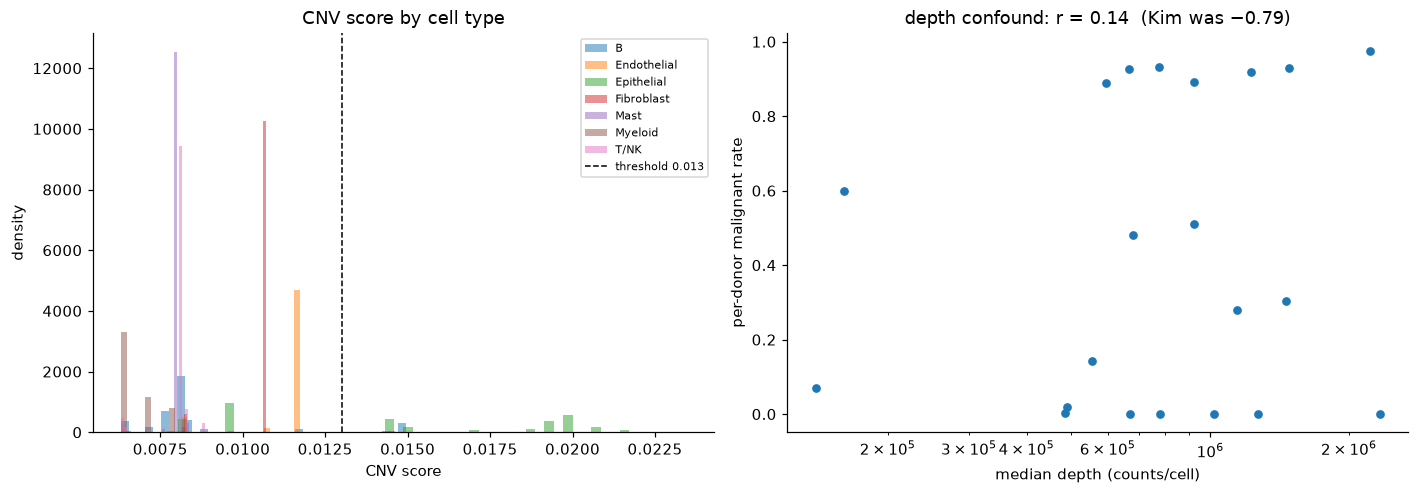

cnv_status counts: {'reference': np.int64(12536), 'other': np.int64(4148), 'malignant': np.int64(2957), 'normal_epithelium': np.int64(2227)}


In [4]:
# left: CNV score by cell type (reference low, epithelial bimodal). right: depth is NOT the driver.
VALLEY = 0.013  # density valley between diploid and aneuploid epithelium (the malignant threshold)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for ct, sub in A.obs.groupby('cell_type', observed=True):
    ax[0].hist(sub['cnv_score'], bins=60, alpha=.5, density=True, label=ct)
ax[0].axvline(VALLEY, color='k', ls='--', lw=1, label=f'threshold {VALLEY}')
ax[0].set_xlabel('CNV score'); ax[0].set_ylabel('density')
ax[0].set_title('CNV score by cell type'); ax[0].legend(fontsize=7)

# depth confound check: per-donor malignant rate vs median depth (epithelial cells)
epi = A.obs[A.obs['cell_type'] == 'Epithelial'].copy()
epi['malig'] = epi['cnv_score'] > VALLEY
g = (epi.groupby('donor_id', observed=True)
        .agg(malig_rate=('malig', 'mean'), med_depth=('total_counts', 'median'), n=('malig', 'size')))
g = g[g['n'] >= 20]
r = g['malig_rate'].corr(g['med_depth'])
ax[1].scatter(g['med_depth'], g['malig_rate'], s=22)
ax[1].set_xlabel('median depth (counts/cell)'); ax[1].set_ylabel('per-donor malignant rate')
ax[1].set_xscale('log')
ax[1].set_title(f'depth confound: r = {r:.2f}  (Kim was −0.79)')
plt.tight_layout(); plt.show()

print('cnv_status counts:', dict(A.obs['cnv_status'].value_counts()))

**Read-out.** The reference compartment (T/NK, Myeloid, B) and stroma pile up tight and low; epithelial cells spread to a clearly separated high-CNV malignant mode. Crucially the per-donor malignant rate is **decoupled from depth** (|r| far below Kim's 0.79), confirming these calls are driven by real copy-number signal rather than coverage noise. This is the clean malignant population Kim could not deliver — and it is what makes a per-stage cancer-cell comparison meaningful here.

## 3 · Model-node signatures across TN→RD→PD (EGFR malignant cells) — the cell-level view

We restrict to **confirmed-malignant, EGFR-driver** cancer cells (the model's population), and score the node signatures across the treatment axis. `at2_regenerative` is the **positive control**: the original authors found residual-disease persisters adopt an alveolar-regenerative AT2-like state, so it should peak at RD if the pipeline is capturing persister biology.

EGFR malignant cells by stage: {'PD': np.int64(1053), 'RD': np.int64(478), 'TN': np.int64(400)}


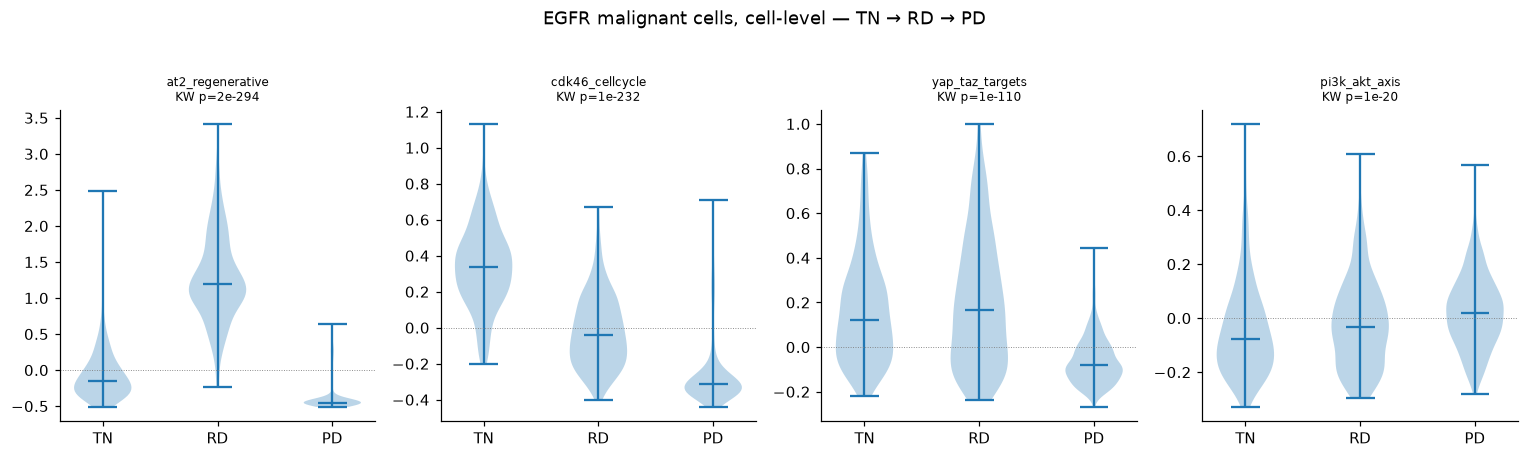


median signature score by stage (EGFR malignant, cell-level):
           pi3k_akt_axis  yap_taz_targets  cdk46_cellcycle  proliferation  at2_regenerative
condition                                                                                  
TN                -0.078            0.121            0.338         -0.042            -0.152
RD                -0.031            0.165           -0.038         -0.054             1.188
PD                 0.019           -0.081           -0.315         -0.063            -0.450


In [5]:
mal = A[(A.obs['cnv_status'] == 'malignant') & (A.obs['driver_gene'] == 'EGFR')].copy()
print('EGFR malignant cells by stage:', dict(mal.obs['condition'].value_counts()))

SIGS = {
    'pi3k_akt_axis':    ['AKT1','PIK3CA','PDPK1','FOXO3','GSK3B','RPS6KB1'],
    'yap_taz_targets':  ['CTGF','CCN2','CYR61','CCN1','ANKRD1','AMOTL2','THBS1','CAV1','TEAD1'],
    'cdk46_cellcycle':  ['CCND1','CDK4','CDK6','RB1','CDKN1A','CDKN2A','E2F1'],
    'proliferation':    ['MKI67','TOP2A','PCNA','CCNB1','CDK1','BIRC5'],
    'at2_regenerative': ['SFTPC','SFTPB','SFTPA1','NAPSA','LAMP3','ETV5'],   # positive control
}
for name, genes in SIGS.items():
    score_sig(mal, genes, name)

m = mal.obs.copy()
order = ['TN', 'RD', 'PD']
plot_sigs = ['at2_regenerative', 'cdk46_cellcycle', 'yap_taz_targets', 'pi3k_akt_axis']
fig, axes = plt.subplots(1, len(plot_sigs), figsize=(3.5*len(plot_sigs), 4.0))
for ax, name in zip(axes, plot_sigs):
    data = [m.loc[m['condition'] == s, name].values for s in order]
    ax.violinplot(data, showmedians=True)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(order)
    H, p = kruskal(*data)
    ax.set_title(f'{name}\nKW p={p:.0e}', fontsize=8)
    ax.axhline(0, color='grey', lw=.6, ls=':')
plt.suptitle('EGFR malignant cells, cell-level — TN → RD → PD', y=1.03)
plt.tight_layout(); plt.show()

print('\nmedian signature score by stage (EGFR malignant, cell-level):')
print(m.groupby('condition', observed=True)[list(SIGS)].median().reindex(order).round(3).to_string())

**Read-out (cell-level).** The positive control fires decisively: `at2_regenerative` jumps at RD (−0.15 → +1.19 → −0.45) — the persister state is captured. Alongside it, `cdk46_cellcycle` collapses monotonically (0.34 → −0.04 → −0.32), `yap_taz_targets` peaks at RD (0.12 → 0.17 → −0.08), and `pi3k_akt_axis` rises (−0.08 → −0.03 → +0.02). At face value this looks like a coherent persister-state shift with the YAP peak the model would want. **But the p-values are computed over thousands of cells drawn from a handful of patients — so the next section asks whether any of it survives when the patient is the unit of analysis.**

## 4 · The honest check — collapse cells to patients (the cell-level p-values are pseudoreplication)

Cells within a patient are not independent. The correct unit is the **patient×stage mean**. We aggregate, then test RD vs TN *across patients* (EGFR: N=5 RD, 5 TN, 3 PD). With N=5 the test is underpowered by construction — so we report **effect direction and size**, not just significance.

In [6]:
# collapse to patient x stage means, then compare RD vs TN across patients
pdm = (m.groupby(['donor_id', 'condition'], observed=True)[list(SIGS)]
         .mean().reset_index())
print('patients per stage:', dict(pdm['condition'].value_counts()))

rows = []
for sig in SIGS:
    tn = pdm.loc[pdm['condition'] == 'TN', sig]
    rd = pdm.loc[pdm['condition'] == 'RD', sig]
    p = (mannwhitneyu(rd, tn, alternative='two-sided').pvalue
         if (len(rd) >= 3 and len(tn) >= 3) else np.nan)
    rows.append({'signature': sig, 'TN_donor_median': round(tn.median(), 3),
                 'RD_donor_median': round(rd.median(), 3),
                 'direction': 'up at RD' if rd.median() > tn.median() else 'down at RD',
                 'RDvsTN_per_donor_p': round(p, 3)})
perdonor = pd.DataFrame(rows).set_index('signature')
print()
print(perdonor.to_string())

# paired view for the patients sampled at BOTH TN and RD (within-patient trajectory, the strongest design)
wide = pdm.pivot_table(index='donor_id', columns='condition', values='cdk46_cellcycle')
paired = wide.dropna(subset=['TN', 'RD'])
if len(paired):
    print(f'\npatients sampled at both TN and RD (n={len(paired)}): cdk46 within-patient TN→RD')
    print(paired[['TN','RD']].round(3).to_string())

patients per stage: {'RD': np.int64(5), 'TN': np.int64(5), 'PD': np.int64(3)}

                  TN_donor_median  RD_donor_median   direction  RDvsTN_per_donor_p
signature                                                                         
pi3k_akt_axis              -0.073           -0.036    up at RD               0.421
yap_taz_targets             0.155            0.134  down at RD               1.000
cdk46_cellcycle             0.255           -0.041  down at RD               0.151
proliferation               0.060           -0.028  down at RD               0.151
at2_regenerative            0.595            1.214    up at RD               0.841

patients sampled at both TN and RD (n=2): cdk46 within-patient TN→RD
condition     TN     RD
donor_id               
TH218     -0.135 -0.156
TH226      0.350  0.133


C:\Users\olesk\AppData\Local\Temp\ipykernel_33184\466630008.py:21: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = pdm.pivot_table(index='donor_id', columns='condition', values='cdk46_cellcycle')


**Read-out (per-donor) — this is the result.** Almost nothing reaches significance at the patient level, because N=5 cannot. More importantly, the *directions* separate the real signal from the artifact:

- **`yap_taz_targets` does not survive** — TN 0.155 vs RD 0.134, p≈1.0. The cell-level YAP peak at RD, the most model-specific signal, **vanishes** when patients are the unit. It was within-patient cell variation, not a consistent patient-level shift.
- **`pi3k_akt_axis`** is directionally up but tiny and non-significant (p≈0.42).
- **`at2_regenerative`** holds *directionally* (0.60 → 1.21) but p≈0.84 — even the authors' own headline finding is directional-not-significant at this N, which calibrates how little N=5 can certify.
- **`cdk46_cellcycle`** is the one effect that holds directionally per-donor (0.255 → −0.041, the smallest p at ≈0.15) and within paired patients.

So the cell-level significances were pseudoreplication. The only durable effect is the CDK4/6 collapse — which the next section interprets, because its *direction* is the opposite of what the stiffness model predicts.

## 5 · Interpretation — the CDK4/6 collapse is persister quiescence, not a stiffness readout

The stiffness model predicts that a **stiffer** environment *raises* cyclin D–CDK4/6 (more dividing cells, a smaller drug-sensitive slow-divider pool). Maynard shows CDK4/6 *collapsing* in the persister state. That is not evidence for the model with a sign flip — it is a **different axis**. Drug-tolerant persisters exit the cell cycle to survive TKI; quiescence is the *defining* feature of the persister phenotype and is orthogonal to matrix stiffness. The plot below makes the direction explicit and pairs CDK4/6 with a generic proliferation signature (they move together: persisters are not cycling).

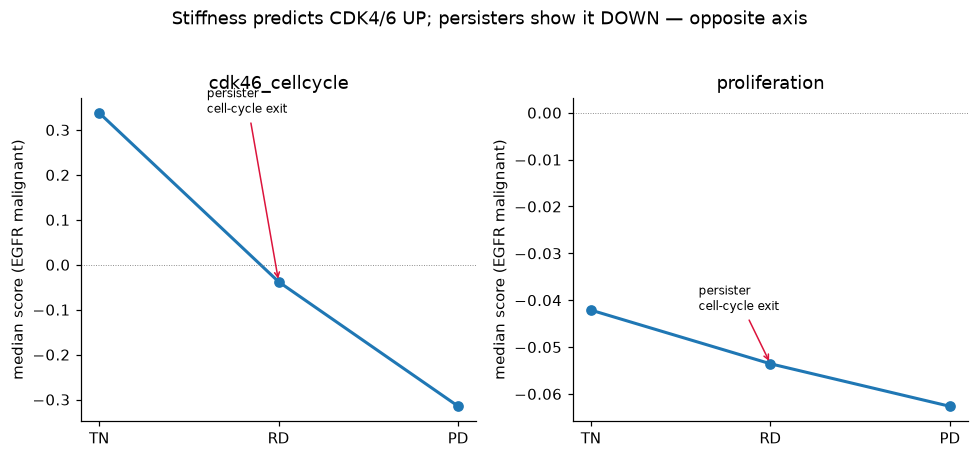

In [7]:
# CDK4/6 and proliferation both fall into the persister (RD) state -> cell-cycle exit, not stiffening
fig, ax = plt.subplots(1, 2, figsize=(9, 4.0))
for j, sig in enumerate(['cdk46_cellcycle', 'proliferation']):
    score_sig(mal, SIGS.get(sig, ['MKI67','TOP2A','PCNA','CCNB1','CDK1','BIRC5']), sig)
    med = mal.obs.groupby('condition', observed=True)[sig].median().reindex(order)
    ax[j].plot(order, med.values, 'o-', lw=2)
    ax[j].axhline(0, color='grey', lw=.6, ls=':')
    ax[j].set_title(sig); ax[j].set_ylabel('median score (EGFR malignant)')
    ax[j].annotate('persister\ncell-cycle exit', xy=(1, med.values[1]),
                   xytext=(0.6, med.max()), fontsize=8,
                   arrowprops=dict(arrowstyle='->', color='crimson'))
fig.suptitle('Stiffness predicts CDK4/6 UP; persisters show it DOWN — opposite axis', y=1.03)
plt.tight_layout(); plt.show()

**Read-out (interpretation).** Both cell-cycle signatures drop into RD and stay low — the persisters are quiescent. This is real, expected drug-tolerant-persister biology, and it is consistent with the *therapeutic* half of the model (CDK4/6 as a lever worth targeting in the tolerant state). But it is **not** a measurement of the cancer-cell response to stiffness, and its direction is opposite to the model's stiffness prediction. Reading it as confirmation of the stiffness axis would be a category error.

## 6 · Why Maynard cannot test the stiffness prediction (even in principle)

The model's untested claim is **(B): cancer cells in a *stiffer* environment raise FAK/AKT/YAP/proliferation relative to cancer cells in a *softer* one.** Testing (B) requires a **stiffness contrast** — two cell populations differing in stiffness, with stiffness measured or manipulated, holding cell identity fixed.

Maynard's axis is **treatment stage**, which is not that. TN, RD, and PD differ in *drug exposure, clonal selection, persister survival, and elapsed time* simultaneously. None of the stages differ **only** in stiffness, and stiffness is never measured per cell. So no comparison across TN/RD/PD — whatever the signatures do — can be attributed to stiffness. The same structural limit applies to Kim's tumor-vs-normal axis (which confounds malignancy with everything else). Dissociated patient-biopsy scRNA-seq simply does not carry the variable the claim is about.

This is a clean boundary, not a failure: the data answer the questions they *can* answer (persister reprogramming, malignant-cell landscape) well, and they leave claim (B) open for data that contains the stiffness contrast.

In [8]:
# make the confounding explicit: the 'axis' here is treatment, and it bundles several variables at once.
summary = pd.DataFrame({
    'stage': ['TN', 'RD', 'PD'],
    'meaning': ['treatment-naive baseline',
                'residual disease (drug-tolerant persister)',
                'progressive disease (acquired resistance)'],
    'differs from TN by': ['—',
                            'drug exposure + persister survival + time',
                            'drug exposure + selection + resistance + time'],
    'stiffness measured?': ['no', 'no', 'no'],
    'EGFR malignant cells': [int((mal.obs['condition']=='TN').sum()),
                             int((mal.obs['condition']=='RD').sum()),
                             int((mal.obs['condition']=='PD').sum())],
    'EGFR patients': [pdm[pdm['condition']=='TN']['donor_id'].nunique(),
                      pdm[pdm['condition']=='RD']['donor_id'].nunique(),
                      pdm[pdm['condition']=='PD']['donor_id'].nunique()],
})
print(summary.to_string(index=False))

stage                                    meaning                            differs from TN by stiffness measured?  EGFR malignant cells  EGFR patients
   TN                   treatment-naive baseline                                             —                  no                   400              5
   RD residual disease (drug-tolerant persister)     drug exposure + persister survival + time                  no                   478              5
   PD  progressive disease (acquired resistance) drug exposure + selection + resistance + time                  no                  1053              3


**Read-out.** Every stage difference bundles multiple variables and none isolate stiffness — so this axis is the wrong instrument for claim (B), independent of sample size. The per-stage cell and patient counts (small N at the patient level) are recorded here for transparency.

## 7 · Conclusions and what closes the gap

**What Maynard establishes (supported):**
- A cleanly resolved malignant compartment with no depth confound (the project's best CNV calling).
- Genuine **persister-state reprogramming** in EGFR-mutant cancer cells: the alveolar-regenerative (AT2) program switches on at residual disease (reproducing the original authors), and cyclin D–CDK4/6 collapses as persisters exit the cell cycle. The CDK4/6 effect is the one signal that holds directionally per-donor.

**What Maynard does *not* establish (open):**
- The mechanotransduction response the stiffness model predicts. The cell-level YAP/AKT shifts are **pseudoreplication** — they do not survive aggregation to the patient (YAP RD-vs-TN p≈1.0 across N=5). And the durable CDK4/6 effect runs **opposite** to the stiffness prediction (it is persister quiescence, not stiffening).
- This is the same answer Kim gave (malignant-cell YAP/AKT flat-to-lower), now confirmed on a treatment axis: **the cancer-cell stiffness response is not demonstrated in either patient dataset**, and cannot be, because neither contains a soft-vs-stiff contrast.

**What closes it.** A controlled stiffness contrast: lung cancer cells on soft vs stiff substrates with transcriptomics (e.g. the A549 1 kPa vs 50 kPa RNA-seq from Cosgrove/Gersbach, Science 2024 — scoreable directly with this pipeline; EGFR-specific confirmation in PC9/HCC827 hydrogel data), or spatial NSCLC where stiff/soft niches are defined by local CAF/ECM density and the *same tumor's* cancer cells are compared across them. Paired with the supported stromal result (Kim/Tsukui: tumors **build** the stiff niche), that contrast tests the remaining half — whether cancer cells **respond** to it.

> **One-line summary.** Maynard is strong persister biology and a clean malignant-calling benchmark, but the treatment axis is not a stiffness axis; the model's cancer-cell-response prediction remains open and needs soft-vs-stiff data to test.